In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, 
classification_report,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay)

In [35]:
x, y = load_breast_cancer(return_X_y=True)

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [37]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [38]:
model = LogisticRegression(max_iter=10000, random_state=0)
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=10000, random_state=0)

In [39]:
y_predict = model.predict(x_test_scaled)

In [40]:
acc = accuracy_score(y_test, y_predict)
pre = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)
roc_auc = roc_auc_score(y_test, y_predict)
cla = classification_report(y_test, y_predict, target_names=['Malignant', 'Benign'])

In [41]:
print("--- Text Evaluation Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nClassification Report:\n", cla)

--- Text Evaluation Metrics ---
Accuracy:  0.9737
Precision: 0.9722
Recall:    0.9859
F1-Score:  0.9790
ROC-AUC:   0.9697

Classification Report:
               precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



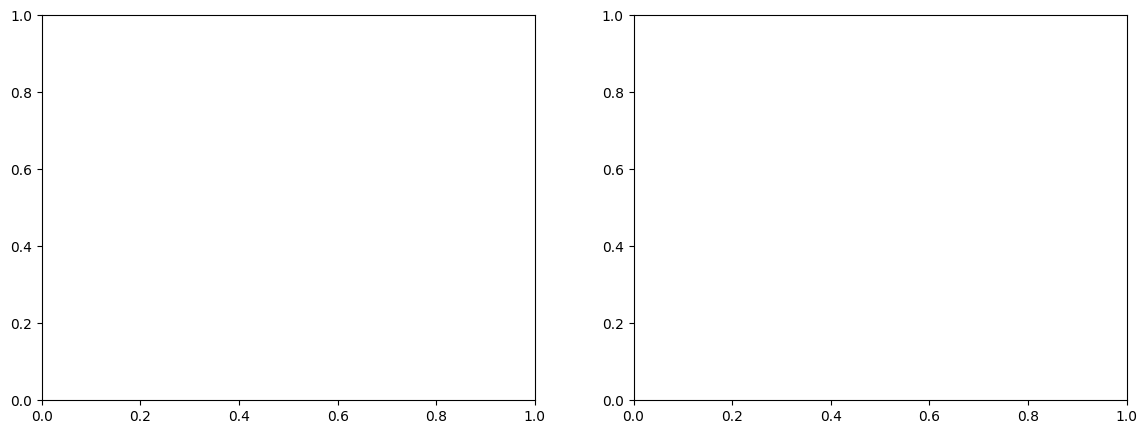

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [43]:
cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title("Confusion Matrix")

Text(0.5, 1.0, 'Confusion Matrix')

In [44]:
RocCurveDisplay.from_estimator(model, x_test_scaled, y_test, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>